# Lab 20
1. Use iris flower dataset from sklearn library and try to form clusters of flowers using petal width and length features. Drop other two features for simplicity.
2. Figure out if any preprocessing such as scaling would help here
3. Draw elbow plot and from that figure out optimal value of k

In [18]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from matplotlib import pyplot as plt
%matplotlib inline

In [19]:
# load iris dataset
from sklearn.datasets import load_iris
iris = load_iris()

In [20]:
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [42]:
# create dataframe from iris data 
df = pd.DataFrame(iris.data,columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [43]:
# drop sepal 
df = df.drop(['sepal length (cm)', 'sepal width (cm)'], axis='columns')

df.head()

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


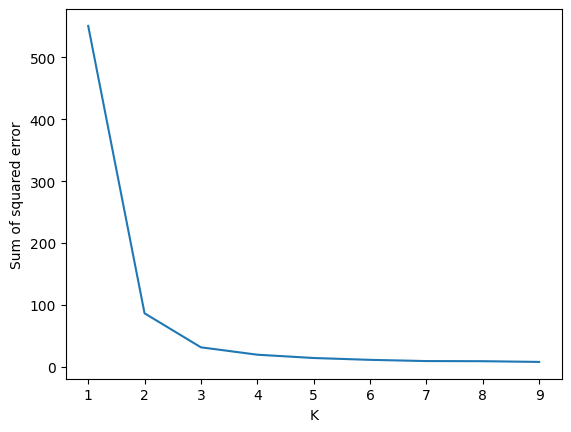

In [44]:
# elbow plot

sse = []
k_rng = range(1,10)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df[['petal length (cm)','petal width (cm)']])
    sse.append(km.inertia_)

plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng,sse)

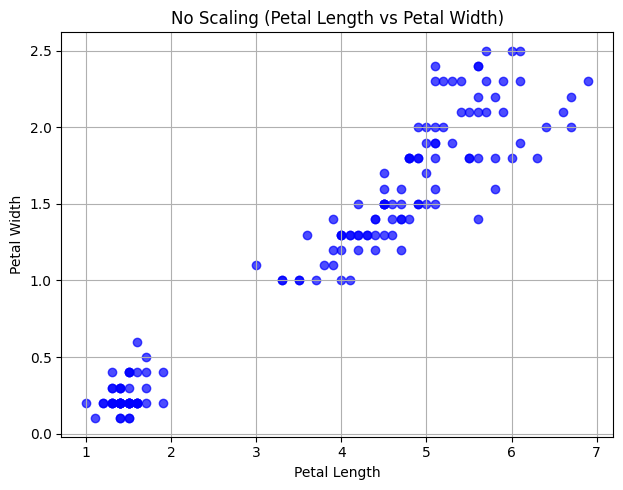

In [ ]:
# plot data 
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df['petal length (cm)'], df['petal width (cm)'], color='blue', alpha=0.7)
plt.title('No Scaling (Petal Length vs Petal Width)')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.grid(True)


plt.tight_layout()
plt.show()

In [25]:
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(df[['petal length (cm)','petal width (cm)']])
y_predicted

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

In [26]:
df['cluster']=y_predicted
df.head()

,petal length (cm),petal width (cm),cluster
0,1.4,0.2,1
1,1.4,0.2,1
2,1.3,0.2,1
3,1.5,0.2,1
4,1.4,0.2,1


In [27]:
km.cluster_centers_

array([[4.26923077, 1.34230769],
       [1.462     , 0.246     ],
       [5.59583333, 2.0375    ]])

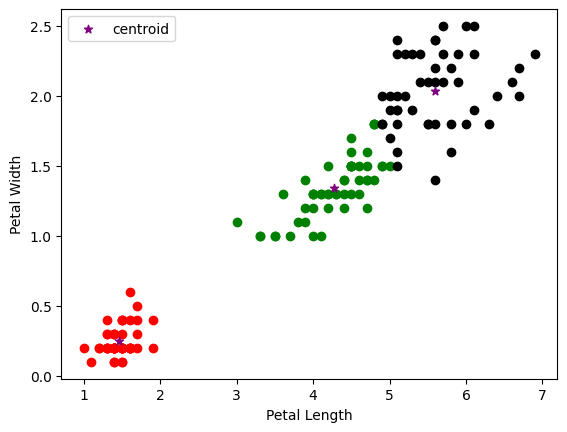

In [28]:
df1 = df[df.cluster==0]
df2 = df[df.cluster==1]
df3 = df[df.cluster==2]
plt.scatter(df1['petal length (cm)'],df1['petal width (cm)'],color='green')
plt.scatter(df2['petal length (cm)'],df2['petal width (cm)'],color='red')
plt.scatter(df3['petal length (cm)'],df3['petal width (cm)'],color='black')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.legend()

In [29]:
# preprocessing using min-max & z-score 
mm_scaler = MinMaxScaler()     # Scales values to range [0, 1]
z_scaler = StandardScaler()    # scales values to mean=0 and std=1

# apply min–max scaling
df['Petal_Length_MinMax'] = mm_scaler.fit_transform(df[['petal length (cm)']])
df['Petal_Width_MinMax'] = mm_scaler.fit_transform(df[['petal width (cm)']])

# apply z-score scaling
df['Petal_Length_Zscore'] = z_scaler.fit_transform(df[['petal length (cm)']])
df['Petal_Width_Zscore'] = z_scaler.fit_transform(df[['petal width (cm)']])

df.head()

,petal length (cm),petal width (cm),cluster,Petal_Length_MinMax,Petal_Width_MinMax,Petal_Length_Zscore,Petal_Width_Zscore
0,1.4,0.2,1,0.067797,0.041667,-1.340227,-1.315444
1,1.4,0.2,1,0.067797,0.041667,-1.340227,-1.315444
2,1.3,0.2,1,0.050847,0.041667,-1.397064,-1.315444
3,1.5,0.2,1,0.084746,0.041667,-1.283389,-1.315444
4,1.4,0.2,1,0.067797,0.041667,-1.340227,-1.315444


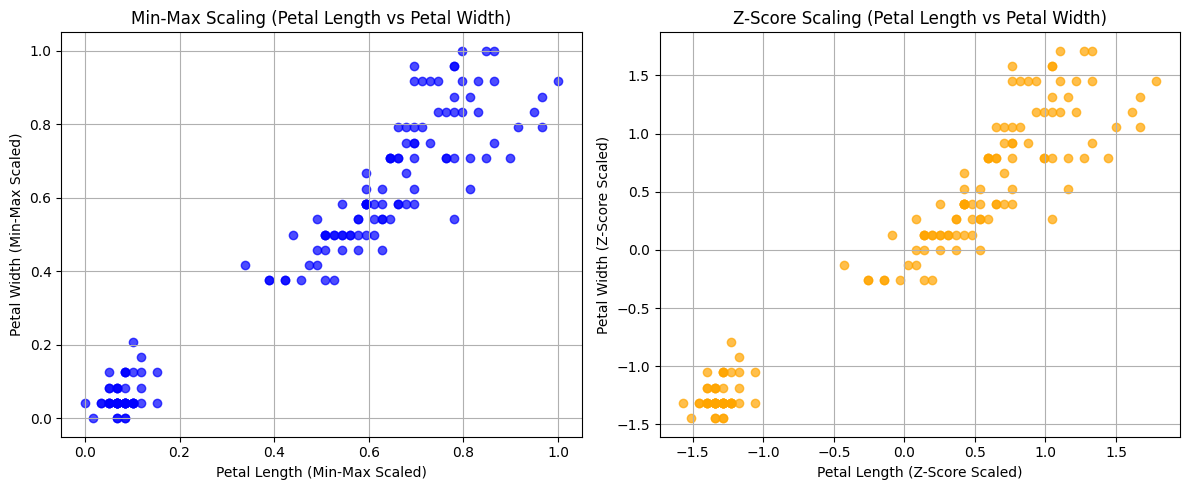

In [30]:
# plot data 

plt.figure(figsize=(12, 5)) 

# ---- Left: Min-Max Scaling ----
plt.subplot(1, 2, 1)
plt.scatter(df['Petal_Length_MinMax'], df['Petal_Width_MinMax'], color='blue', alpha=0.7)
plt.title('Min-Max Scaling (Petal Length vs Petal Width)')
plt.xlabel('Petal Length (Min-Max Scaled)')
plt.ylabel('Petal Width (Min-Max Scaled)')
plt.grid(True)

# ---- Right: Z-Score Scaling ----
plt.subplot(1, 2, 2)
plt.scatter(df['Petal_Length_Zscore'], df['Petal_Width_Zscore'], color='orange', alpha=0.7)
plt.title('Z-Score Scaling (Petal Length vs Petal Width)')
plt.xlabel('Petal Length (Z-Score Scaled)')
plt.ylabel('Petal Width (Z-Score Scaled)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [33]:
# redefining k-means 
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(df[['Petal_Length_MinMax','Petal_Width_MinMax']])
y_predicted

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [34]:
df['cluster']=y_predicted
df.head()

,petal length (cm),petal width (cm),cluster,Petal_Length_MinMax,Petal_Width_MinMax,Petal_Length_Zscore,Petal_Width_Zscore
0,1.4,0.2,1,0.067797,0.041667,-1.340227,-1.315444
1,1.4,0.2,1,0.067797,0.041667,-1.340227,-1.315444
2,1.3,0.2,1,0.050847,0.041667,-1.397064,-1.315444
3,1.5,0.2,1,0.084746,0.041667,-1.283389,-1.315444
4,1.4,0.2,1,0.067797,0.041667,-1.340227,-1.315444


In [35]:
km.cluster_centers_

array([[0.7740113 , 0.81510417],
       [0.07830508, 0.06083333],
       [0.55867014, 0.51041667]])

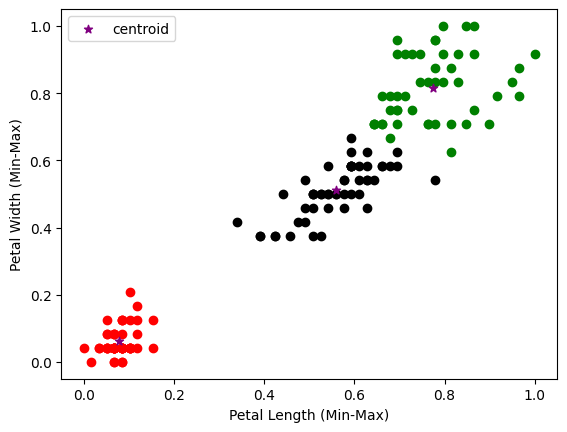

In [37]:
# plot again 

df1 = df[df.cluster==0]
df2 = df[df.cluster==1]
df3 = df[df.cluster==2]
plt.scatter(df1['Petal_Length_MinMax'],df1['Petal_Width_MinMax'],color='green')
plt.scatter(df2['Petal_Length_MinMax'],df2['Petal_Width_MinMax'],color='red')
plt.scatter(df3['Petal_Length_MinMax'],df3['Petal_Width_MinMax'],color='black')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.xlabel('Petal Length (Min-Max)')
plt.ylabel('Petal Width (Min-Max)')
plt.legend()

In [41]:
# elbow plot

sse = []
k_rng = range(1,10)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df[['Petal_Length_MinMax','Petal_Width_MinMax']])
    sse.append(km.inertia_)

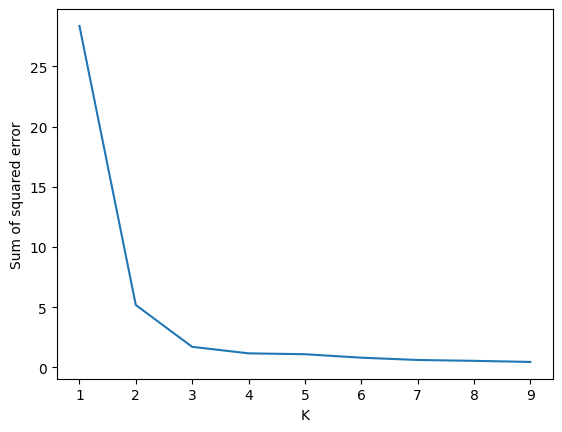

In [39]:
plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng,sse)

## given the plot above, the most optimal k is 3, which we used 